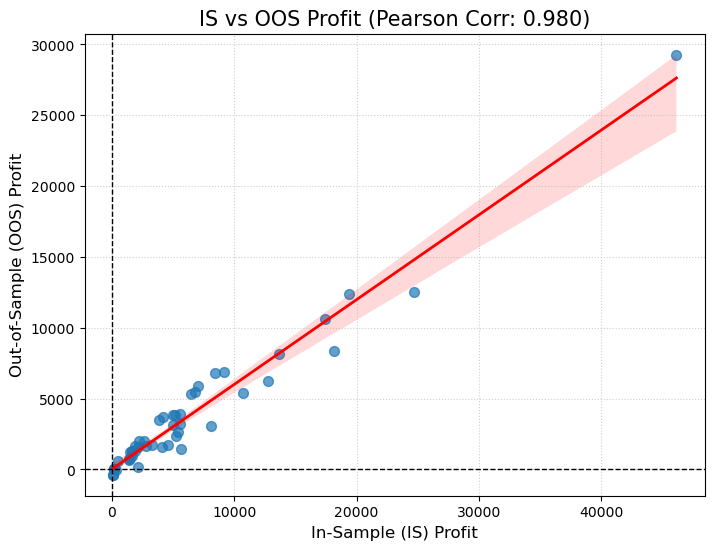

IS OOS Corr 0.980


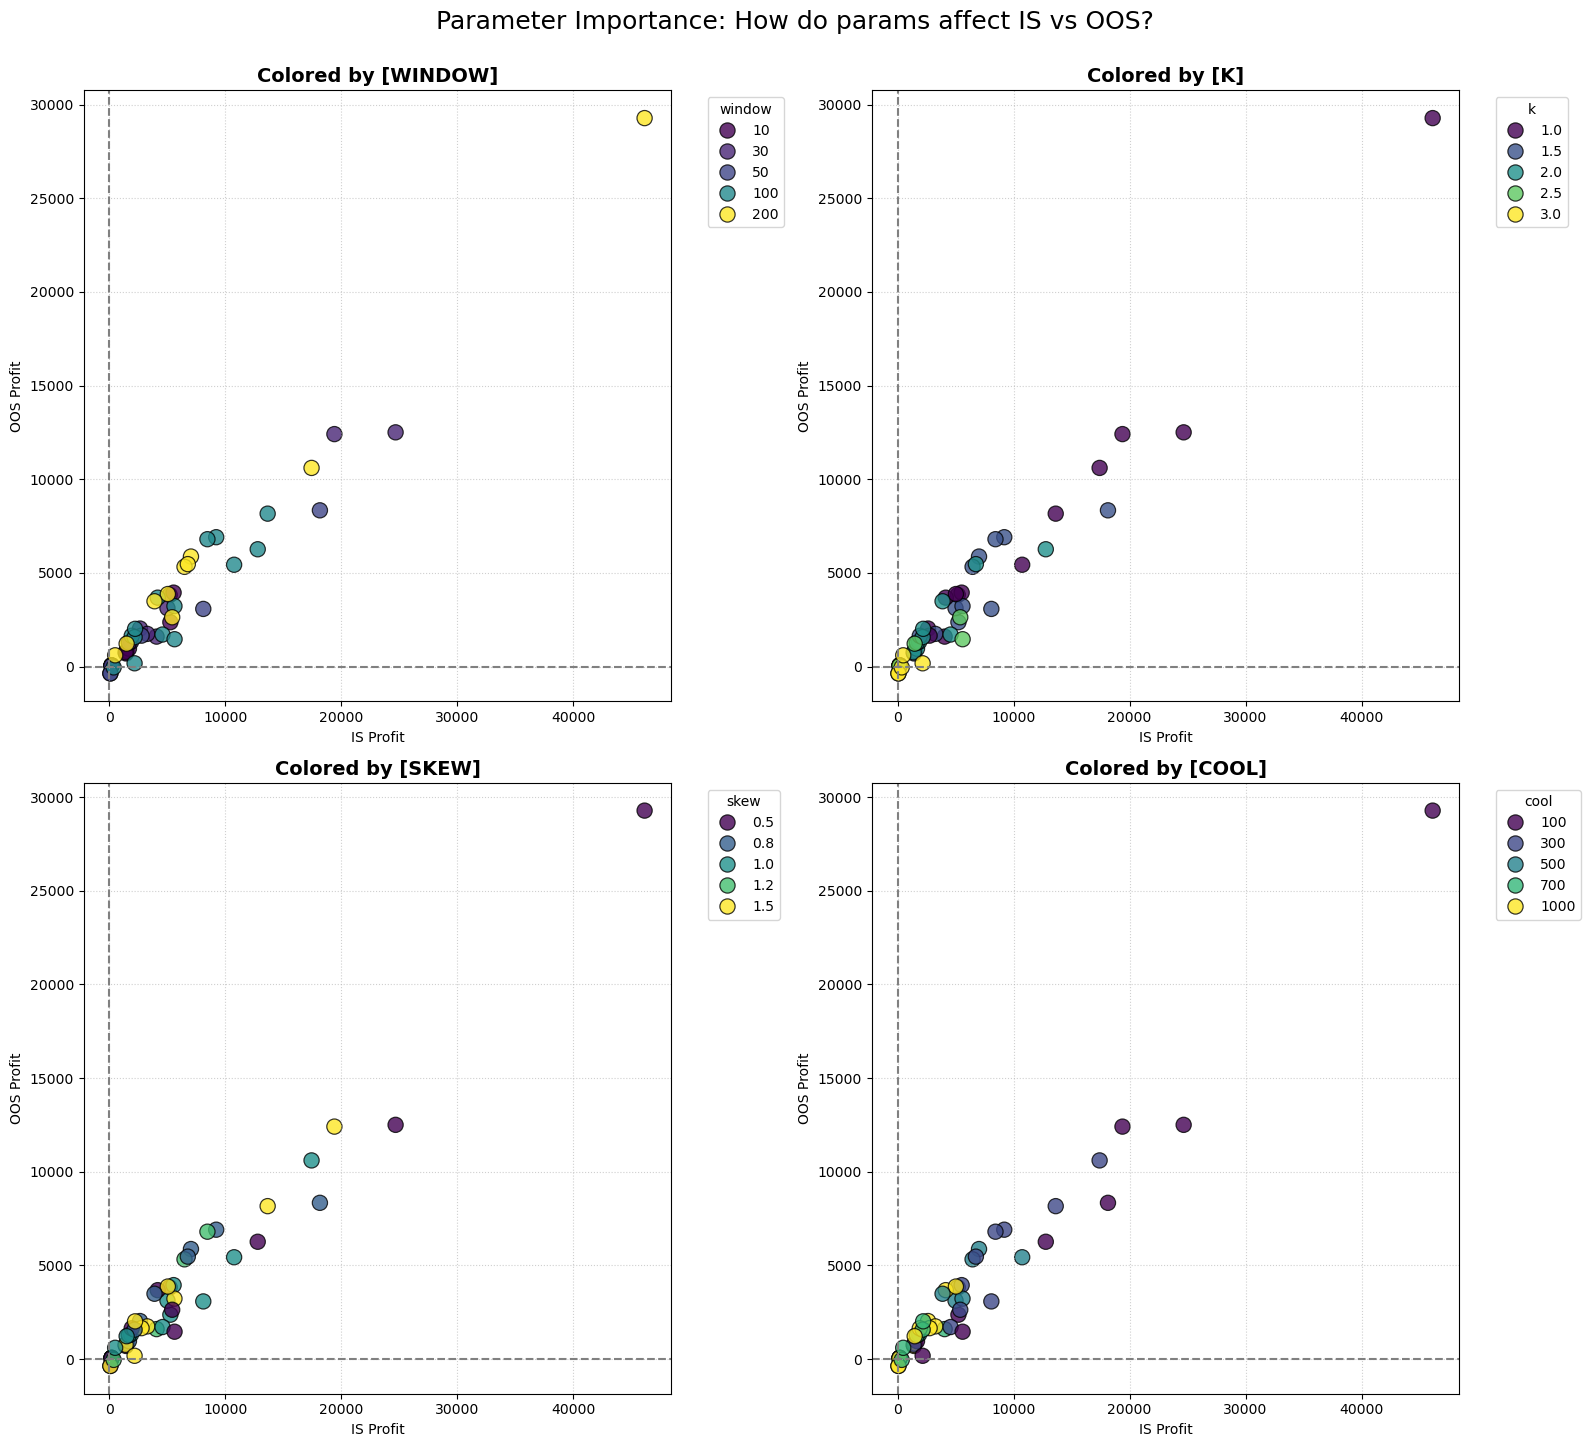

/var/folders/qz/5dkq_4wj0yq8v0bd99hhn7g00000gn/T/ipykernel_25660/3236044813.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grouped, x=param, y='Total_Profit', ax=axes[i], palette='Set2')
/var/folders/qz/5dkq_4wj0yq8v0bd99hhn7g00000gn/T/ipykernel_25660/3236044813.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grouped, x=param, y='Total_Profit', ax=axes[i], palette='Set2')
/var/folders/qz/5dkq_4wj0yq8v0bd99hhn7g00000gn/T/ipykernel_25660/3236044813.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grouped, x=param,

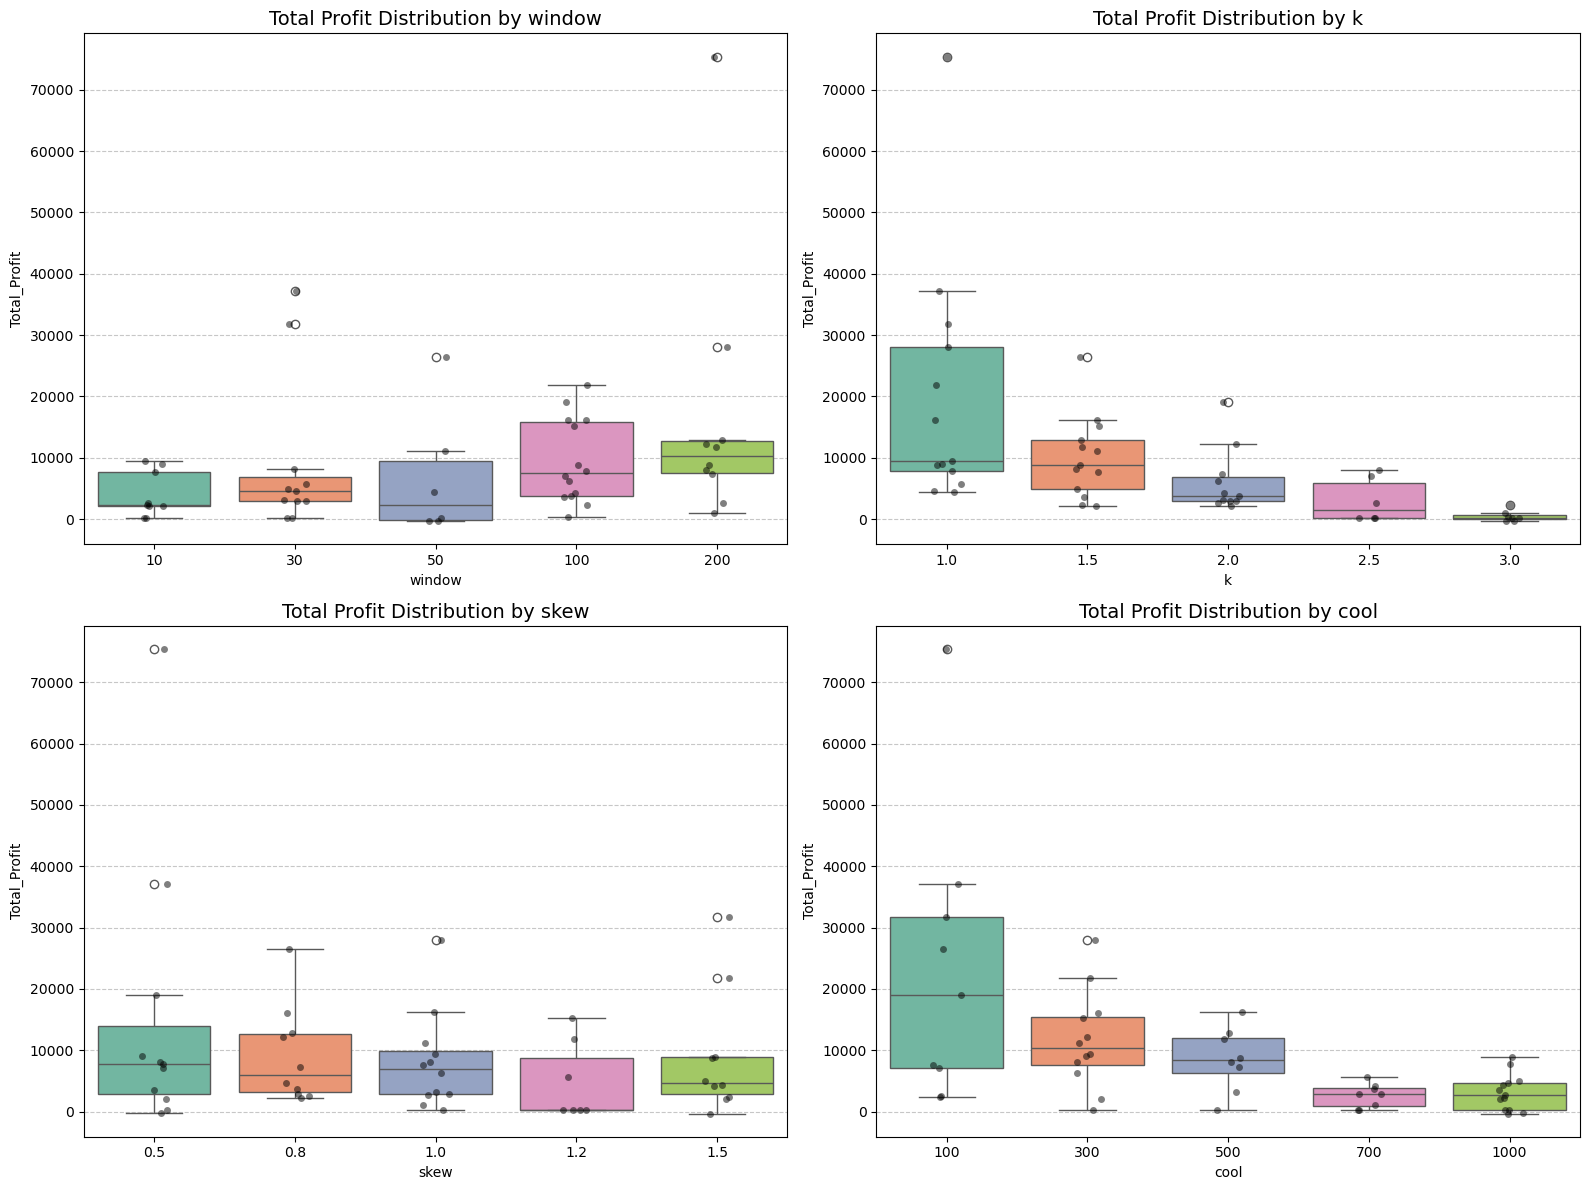

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv('leaning_grid_results_50.csv')
# 1. 파라미터 조합별로 IS와 OOS 총 수익 합산
grouped = df.groupby(['window', 'k', 'skew', 'cool', 'sample_type'])['profit'].sum().unstack(fill_value=0).reset_index()

# 결측 컬럼 방지 및 Total 계산
if 'IS' not in grouped.columns: grouped['IS'] = 0
if 'OOS' not in grouped.columns: grouped['OOS'] = 0
grouped['Total_Profit'] = grouped['IS'] + grouped['OOS']


# ==========================================
# 분석 1: IS와 OOS 간의 연관성 (Correlation)
# ==========================================
# 상관계수 계산
correlation = grouped['IS'].corr(grouped['OOS'])

plt.figure(figsize=(8, 6))
# 회귀선(추세선)을 포함한 산점도
sns.regplot(data=grouped, x='IS', y='OOS', scatter_kws={'alpha':0.7, 's':50}, line_kws={'color':'red', 'linewidth':2})

plt.title(f'IS vs OOS Profit (Pearson Corr: {correlation:.3f})', fontsize=15)
plt.xlabel('In-Sample (IS) Profit', fontsize=12)
plt.ylabel('Out-of-Sample (OOS) Profit', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"IS OOS Corr {correlation:.3f}")


# ==========================================
# 분석 2: 파라미터별 중요도 분석 (Subplot & Scatter)
# ==========================================
# 2x2 서브플롯 생성
params = ['window', 'k', 'skew', 'cool']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# 각 파라미터별로 색상(hue)을 다르게 하여 IS vs OOS 산점도 그리기
for i, param in enumerate(params):
    # 파라미터 값이 연속형처럼 보일 수 있으므로 카테고리화 처리하여 명확한 색상 구분
    sns.scatterplot(
        data=grouped, 
        x='IS', 
        y='OOS', 
        hue=param, 
        palette='viridis', # 색상 테마 (밝을수록 높은 값)
        ax=axes[i], 
        s=120, 
        alpha=0.8,
        edgecolor='black'
    )
    
    axes[i].set_title(f'Colored by [{param.upper()}]', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('IS Profit')
    axes[i].set_ylabel('OOS Profit')
    axes[i].axhline(0, color='gray', linestyle='--')
    axes[i].axvline(0, color='gray', linestyle='--')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    
    # 범례 위치 조정
    axes[i].legend(title=param, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.suptitle('Parameter Importance: How do params affect IS vs OOS?', y=1.03, fontsize=18)
plt.show()


# ==========================================
# 보너스 분석 3: 파라미터별 '총 수익(Total)' 분포 (Boxplot)
# ==========================================
# 어떤 파라미터 값을 썼을 때 수익이 안정적으로 높게 나오는지 확인
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, param in enumerate(params):
    sns.boxplot(data=grouped, x=param, y='Total_Profit', ax=axes[i], palette='Set2')
    # 실제 점(데이터)도 위에 흩뿌려서 보여줌
    sns.stripplot(data=grouped, x=param, y='Total_Profit', ax=axes[i], color='black', alpha=0.5, size=5)
    
    axes[i].set_title(f'Total Profit Distribution by {param}', fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()